In [42]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


Praproses :
1. seleksi data
2. Agregasi Data
3. Normalisasi 

In [43]:
df = pd.read_csv("data_pengangguran.csv")
df_2024 = df[df["tahun"] == 2024]

print("Dataset Awal (Tahun 2024):")
print(df_2024.head())

#agregasi data
df_agregat = (
    df_2024
    .groupby("nama_kabupaten_kota")["jumlah_pengangguran"]
    .sum()
    .reset_index()
)

print("")
print("Hasil agregasi data:")
print(df_agregat.head())

#Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_agregat[["jumlah_pengangguran"]])

print("\nData setelah normalisasi:")
print(X_scaled[:5])



Dataset Awal (Tahun 2024):
     id  kode_provinsi nama_provinsi  kode_kabupaten_kota nama_kabupaten_kota  \
0  1567             32    JAWA BARAT                 3201     KABUPATEN BOGOR   
1  1568             32    JAWA BARAT                 3201     KABUPATEN BOGOR   
2  1569             32    JAWA BARAT                 3201     KABUPATEN BOGOR   
3  1570             32    JAWA BARAT                 3201     KABUPATEN BOGOR   
4  1571             32    JAWA BARAT                 3201     KABUPATEN BOGOR   

                             pendidikan  jumlah_pengangguran satuan  tahun  
0                           SD KE BAWAH                43083  ORANG   2024  
1                                   SMP                31436  ORANG   2024  
2                            SMA (UMUM)                52849  ORANG   2024  
3                        SMA (KEJURUAN)                71606  ORANG   2024  
4  DIPLOMA I/II/III/AKADEMI/UNIVERSITAS                11212  ORANG   2024  

Hasil agregasi data:
  

Penentuan Jumlah klaster & Proses K-Means

In [44]:
#penentuan jumlah klaster
k = 3

#Proses K-Means (Inisialisasi, centroid awal)
kmeans = KMeans(
    n_clusters=k,
    init="k-means++",
    n_init=10,
    random_state=42,
    max_iter=300
)

# Proses clustering
labels = kmeans.fit_predict(X_scaled)

# Tambahkan hasil cluster ke data
df_agregat["cluster"] = labels

# Centroid Awal (C1, C2, C3)
centroid_scaled = kmeans.cluster_centers_
centroid_asli = scaler.inverse_transform(centroid_scaled)

centroid_df = pd.DataFrame(
    centroid_asli,
    columns=["jumlah_pengangguran"]
)

centroid_df["cluster"] = range(k)

print("\nCentroid Awal K-Means (Skala Asli):")
print(centroid_df)


Centroid Awal K-Means (Skala Asli):
   jumlah_pengangguran  cluster
0         35885.647059        0
1        105331.555556        1
2        210186.000000        2


Evaluasi dan Interpretasi

In [45]:
centroid_df = centroid_df.sort_values(
    "jumlah_pengangguran"
).reset_index(drop=True)

centroid_df["Kategori"] = [
    "Pengangguran Rendah",
    "Pengangguran Sedang",
    "Pengangguran Tinggi"
]

print("\nCentroid Setelah Interpretasi:")
print(centroid_df)


Centroid Setelah Interpretasi:
   jumlah_pengangguran  cluster             Kategori
0         35885.647059        0  Pengangguran Rendah
1        105331.555556        1  Pengangguran Sedang
2        210186.000000        2  Pengangguran Tinggi


Mapping Label Ke Kategori

In [46]:
cluster_label_map = dict(
    zip(
        centroid_df["cluster"],
        centroid_df["Kategori"]
    )
)

df_agregat["kategori_pengangguran"] = df_agregat["cluster"].map(cluster_label_map)

print("\nHasil Akhir Clustering Wilayah:")
print(df_agregat.head())


Hasil Akhir Clustering Wilayah:
       nama_kabupaten_kota  jumlah_pengangguran  cluster kategori_pengangguran
0        KABUPATEN BANDUNG               121455        1   Pengangguran Sedang
1  KABUPATEN BANDUNG BARAT                65609        0   Pengangguran Rendah
2         KABUPATEN BEKASI               142818        1   Pengangguran Sedang
3          KABUPATEN BOGOR               210186        2   Pengangguran Tinggi
4         KABUPATEN CIAMIS                22974        0   Pengangguran Rendah


Visualisasi Centroid

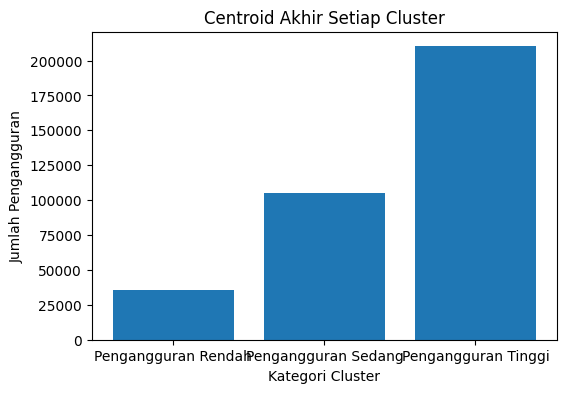

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(
    centroid_df["Kategori"],
    centroid_df["jumlah_pengangguran"]
)
plt.xlabel("Kategori Cluster")
plt.ylabel("Jumlah Pengangguran")
plt.title("Centroid Akhir Setiap Cluster")
plt.show()